In [1]:
# =========================================================
# ANÁLISIS DESCRIPTIVO
# TGEU Trans Murder Monitoring — Colombia (2009-2025)
# Tendencia temporal, perfil demográfico, método y patrón del
# hecho. Todo lo que aparece aquí es descriptivo: con 306 casos
# y sin denominador poblacional, no se ajustan modelos.
# =========================================================

# --- CELDA 1: Cargar el dataset limpio ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

col = pd.read_csv('/content/tgeu_colombia_limpio.csv')
print(f"Casos: {len(col)} | Período: {col['Calendar year'].min()}-{col['Calendar year'].max()}")

Casos: 306 | Período: 2008-2025


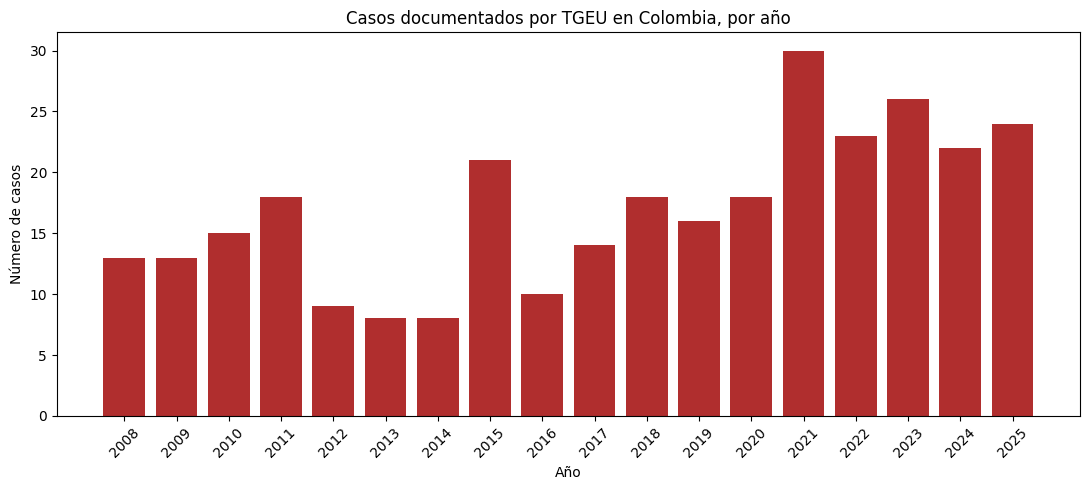

ADVERTENCIA (repetir en el artículo): un aumento en años recientes
puede reflejar más violencia real, mejor capacidad de monitoreo
regional (Caribe Afirmativo y TGEU se fortalecieron con los años),
o ambas cosas a la vez. Este gráfico por sí solo no permite distinguirlas.


In [2]:
# --- CELDA 2: Tendencia temporal (con la advertencia obligatoria) ---
casos_por_año = col['Calendar year'].value_counts().sort_index()

plt.figure(figsize=(11, 5))
plt.bar(casos_por_año.index.astype(int).astype(str), casos_por_año.values, color='#B02E2E')
plt.title('Casos documentados por TGEU en Colombia, por año')
plt.xlabel('Año')
plt.ylabel('Número de casos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("ADVERTENCIA (repetir en el artículo): un aumento en años recientes")
print("puede reflejar más violencia real, mejor capacidad de monitoreo")
print("regional (Caribe Afirmativo y TGEU se fortalecieron con los años),")
print("o ambas cosas a la vez. Este gráfico por sí solo no permite distinguirlas.")

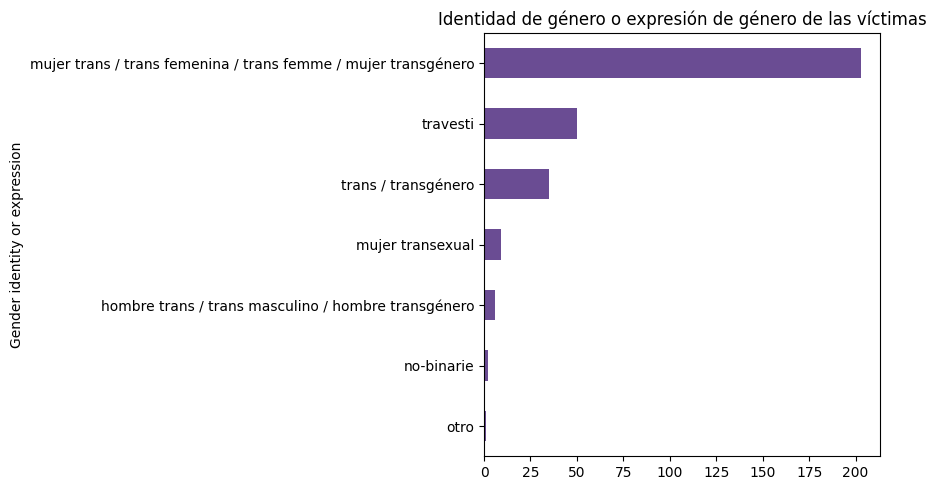


'Travesti' aparece como categoría propia (50 casos):
es una identidad reconocida en el contexto latinoamericano, distinta
de 'mujer trans' — no se deben fusionar aunque a veces se traten como
sinónimos en cobertura mediática internacional.


In [3]:
# --- CELDA 3: Identidad de género de las víctimas ---
identidad = col['Gender identity or expression'].value_counts(dropna=False)
identidad.index = identidad.index.fillna('Sin dato')

plt.figure(figsize=(9, 5))
identidad.plot(kind='barh', color='#6A4C93')
plt.title('Identidad de género o expresión de género de las víctimas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n'Travesti' aparece como categoría propia ({(col['Gender identity or expression']=='travesti').sum()} casos):")
print("es una identidad reconocida en el contexto latinoamericano, distinta")
print("de 'mujer trans' — no se deben fusionar aunque a veces se traten como")
print("sinónimos en cobertura mediática internacional.")

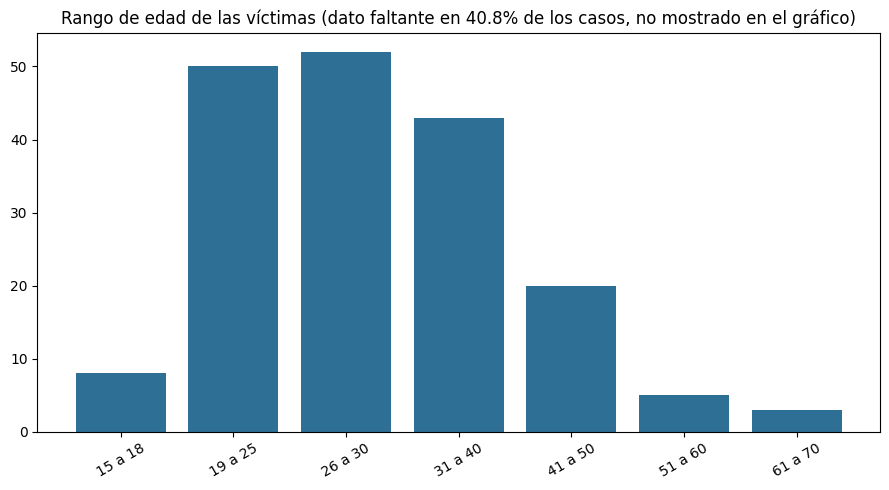

In [4]:
# --- CELDA 4: Edad (con el porcentaje de desconocido visible en el propio gráfico) ---
orden_edad = ['15 a 18', '19 a 25', '26 a 30', '31 a 40', '41 a 50', '51 a 60', '61 a 70']
edad_counts = col['Age range'].value_counts()
edad_counts = edad_counts.reindex(orden_edad).fillna(0)
pct_desconocido = col['Age range'].isna().mean() * 100

plt.figure(figsize=(9, 5))
plt.bar(edad_counts.index, edad_counts.values, color='#2E6F95')
plt.title(f'Rango de edad de las víctimas (dato faltante en {pct_desconocido:.1f}% de los casos, no mostrado en el gráfico)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

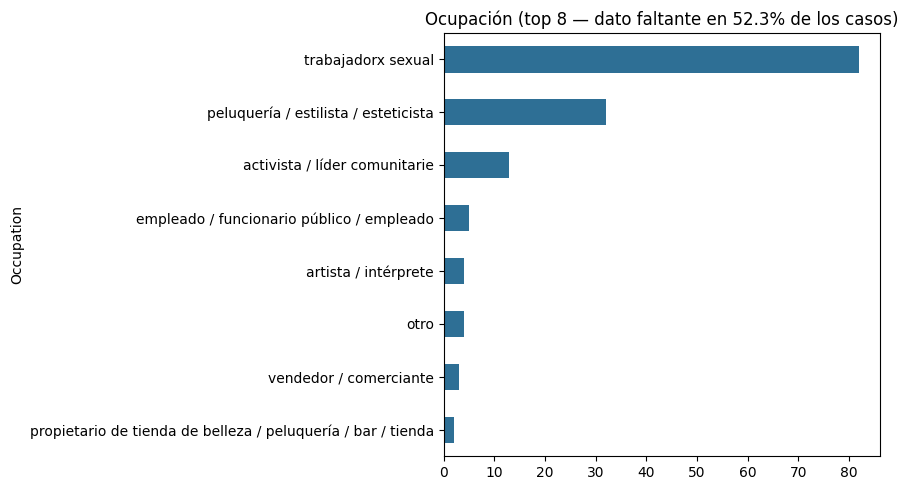

In [5]:
# --- CELDA 5: Ocupación ---
ocupacion = col['Occupation'].value_counts()
pct_desconocido_ocup = col['Occupation'].isna().mean() * 100

plt.figure(figsize=(9, 5))
ocupacion.head(8).plot(kind='barh', color='#2E6F95')
plt.title(f'Ocupación (top 8 — dato faltante en {pct_desconocido_ocup:.1f}% de los casos)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

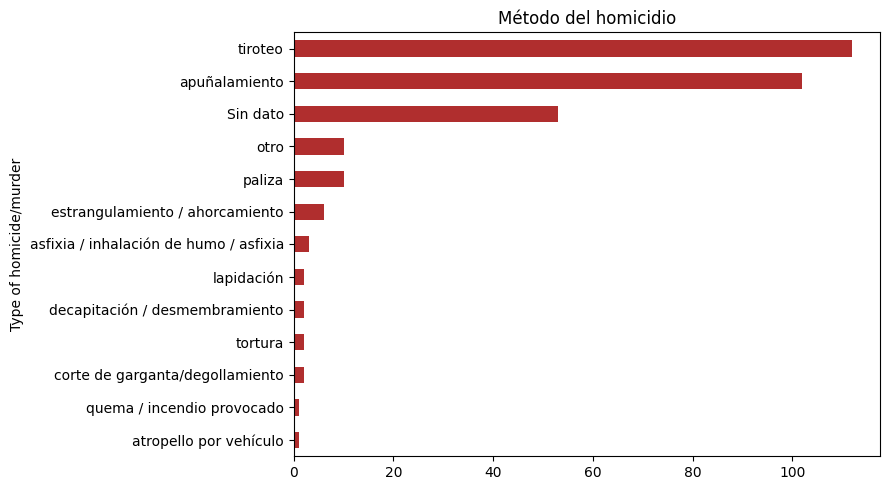


Tiroteo y apuñalamiento juntos representan 214 de 253 casos con método conocido (84.6%).


In [6]:
# --- CELDA 6: Tipo de homicidio / método ---
metodo = col['Type of homicide/murder'].value_counts(dropna=False)
metodo.index = metodo.index.fillna('Sin dato')

plt.figure(figsize=(9, 5))
metodo.plot(kind='barh', color='#B02E2E')
plt.title('Método del homicidio')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top2 = col['Type of homicide/murder'].value_counts().head(2)
print(f"\nTiroteo y apuñalamiento juntos representan "
      f"{top2.sum()} de {col['Type of homicide/murder'].notna().sum()} casos con método conocido "
      f"({top2.sum()/col['Type of homicide/murder'].notna().sum()*100:.1f}%).")

Tipo de perpetrador: 71.9% de los casos SIN dato.
Base del prejuicio (motivo): 81.7% de los casos SIN dato.


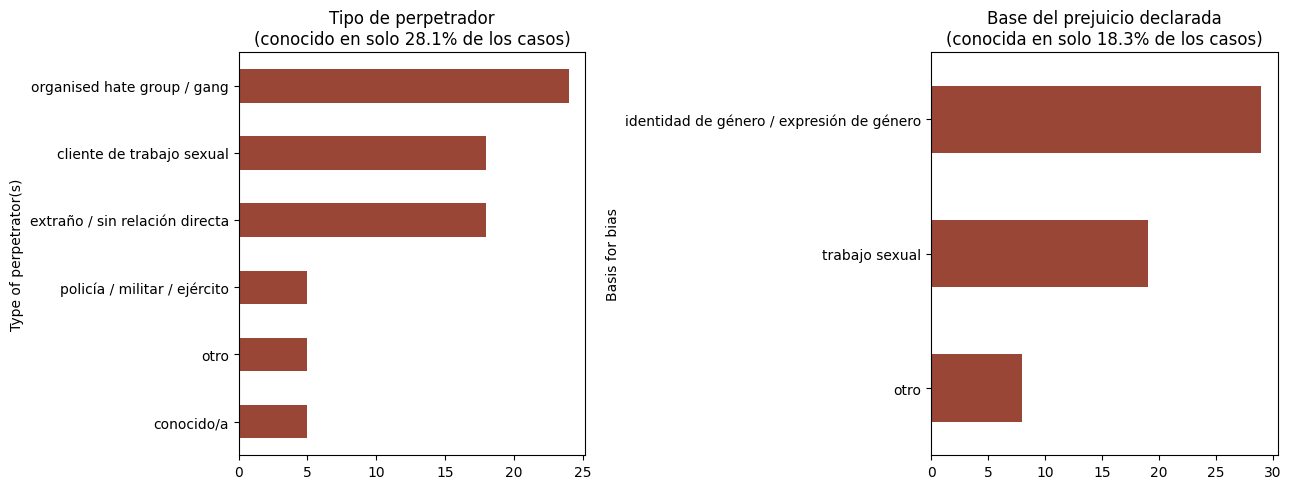


Entre los casos donde SÍ se documentó el motivo, 'identidad/expresión
de género' y 'trabajo sexual' aparecen como las dos categorías
principales, casi empatadas — sugiere que el estigma hacia el trabajo
sexual y la transfobia operan como motivos distintos pero relacionados,
no como una sola causa. Con esta proporción de dato faltante, esto es
una señal a explorar, no una conclusión firme.


In [7]:
# --- CELDA 7: Tipo de perpetrador y base del prejuicio ---
# ADVERTENCIA: estas dos variables tienen muchísimo dato faltante
# (más del 70%). El hallazgo principal aquí puede ser justamente
# cuánto no se sabe, no el detalle de lo que sí se sabe.
pct_perp_na = col['Type of perpetrator(s)'].isna().mean() * 100
pct_bias_na = col['Basis for bias'].isna().mean() * 100
print(f"Tipo de perpetrador: {pct_perp_na:.1f}% de los casos SIN dato.")
print(f"Base del prejuicio (motivo): {pct_bias_na:.1f}% de los casos SIN dato.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

col['Type of perpetrator(s)'].value_counts().head(6).plot(kind='barh', ax=axes[0], color='#994636')
axes[0].set_title(f'Tipo de perpetrador\n(conocido en solo {100-pct_perp_na:.1f}% de los casos)')
axes[0].invert_yaxis()

col['Basis for bias'].value_counts().plot(kind='barh', ax=axes[1], color='#994636')
axes[1].set_title(f'Base del prejuicio declarada\n(conocida en solo {100-pct_bias_na:.1f}% de los casos)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nEntre los casos donde SÍ se documentó el motivo, 'identidad/expresión")
print("de género' y 'trabajo sexual' aparecen como las dos categorías")
print("principales, casi empatadas — sugiere que el estigma hacia el trabajo")
print("sexual y la transfobia operan como motivos distintos pero relacionados,")
print("no como una sola causa. Con esta proporción de dato faltante, esto es")
print("una señal a explorar, no una conclusión firme.")

In [8]:
# --- CELDA 8: Cruce edad x identidad de género (revisando que no queden celdas vacías) ---
cruce = pd.crosstab(col['Age range'], col['Gender identity or expression'].fillna('Sin dato'))
print("\nTabla cruzada edad x identidad de género:")
print(cruce)
print("\nADVERTENCIA: revisa celdas con menos de 5 casos antes de citarlas en")
print("el artículo — con este tamaño de muestra, una celda de 1 o 2 casos no")
print("es un patrón, es una anécdota estadística.")


Tabla cruzada edad x identidad de género:
Gender identity or expression  hombre trans / trans masculino / hombre transgénero  \
Age range                                                                            
15 a 18                                                                        0     
19 a 25                                                                        1     
26 a 30                                                                        0     
31 a 40                                                                        3     
41 a 50                                                                        1     
51 a 60                                                                        0     
61 a 70                                                                        0     

Gender identity or expression  mujer trans / trans femenina / trans femme / mujer transgénero  \
Age range                                                                            

In [11]:
# --- CELDA 9: Exportar tabla resumen ---
resumen = pd.DataFrame({
    'variable': ['Identidad de género', 'Rango de edad', 'Ocupación', 'Tipo de homicidio',
                 'Tipo de perpetrador', 'Base del prejuicio'],
    '% con dato faltante': [
        col['Gender identity or expression'].isna().mean()*100,
        col['Age range'].isna().mean()*100,
        col['Occupation'].isna().mean()*100,
        col['Type of homicide/murder'].isna().mean()*100,
        col['Type of perpetrator(s)'].isna().mean()*100,
        col['Basis for bias'].isna().mean()*100,
    ]
}).round(1)

print("\n=== Resumen de completitud, para citar directamente en el artículo ===")
print(resumen.to_string(index=False))

resumen.to_csv('/content/resumen_completitud.csv', index=False)
casos_por_año.to_csv('/content/casos_por_año.csv')
print("\nExportado: resumen_completitud.csv, casos_por_año.csv")


=== Resumen de completitud, para citar directamente en el artículo ===
           variable  % con dato faltante
Identidad de género                  0.0
      Rango de edad                 40.8
          Ocupación                 52.3
  Tipo de homicidio                 17.3
Tipo de perpetrador                 71.9
 Base del prejuicio                 81.7

Exportado: resumen_completitud.csv, casos_por_año.csv
